# Amazon Prime Movies & TV Shows Analysis

## Introduction

With the rapid growth of OTT (Over-The-Top) platforms, Amazon Prime Video has become one of the leading streaming services worldwide. It offers a vast collection of movies and TV shows across different genres, languages, and regions.

In this project, we analyze the Amazon Prime Movies and TV Shows dataset to uncover meaningful insights such as:
- Distribution of Movies vs TV Shows
- Content trends over the years
- Most popular genres
- Country-wise content production
- Ratings and audience classification

This analysis helps us understand the content strategy of Amazon Prime and how it has evolved over time.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shivamb/amazon-prime-movies-and-tv-shows/amazon_prime_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [3]:
df.shape

(9668, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


In [6]:
df.describe()

,release_year
count,9668.000000
mean,2008.341849
std,18.922482
min,1920.000000
25%,2007.000000
50%,2016.000000
75%,2019.000000
max,2021.000000


In [7]:
# Check missing values
df.isnull().sum()

show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

In [8]:
# Handle Missing Values 
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [9]:
# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

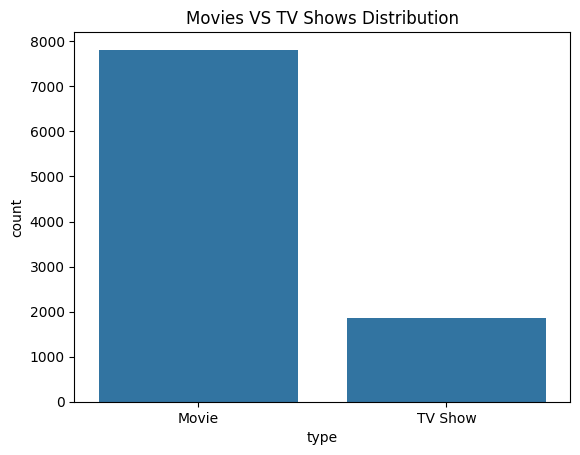

In [10]:
# Movies VS Time Shows
sns.countplot(x='type', data=df)
plt.title("Movies VS TV Shows Distribution")
plt.show()

### Insights
- The dataset contains more Movies than TV Shows
- Amazon Prime focuses more on movie content compared to series.

In [11]:
df['year_added'].head(10)
df['year_added'].isnull().sum()

np.int64(9513)

In [12]:
df['date_added'].head(10)

0   2021-03-30
1   2021-03-30
2   2021-03-30
3   2021-03-30
4   2021-03-30
5   2021-03-30
6   2021-03-30
7   2021-03-30
8   2021-03-30
9   2021-04-01
Name: date_added, dtype: datetime64[ns]

In [13]:
release_data = df['release_year'].value_counts().sort_index()

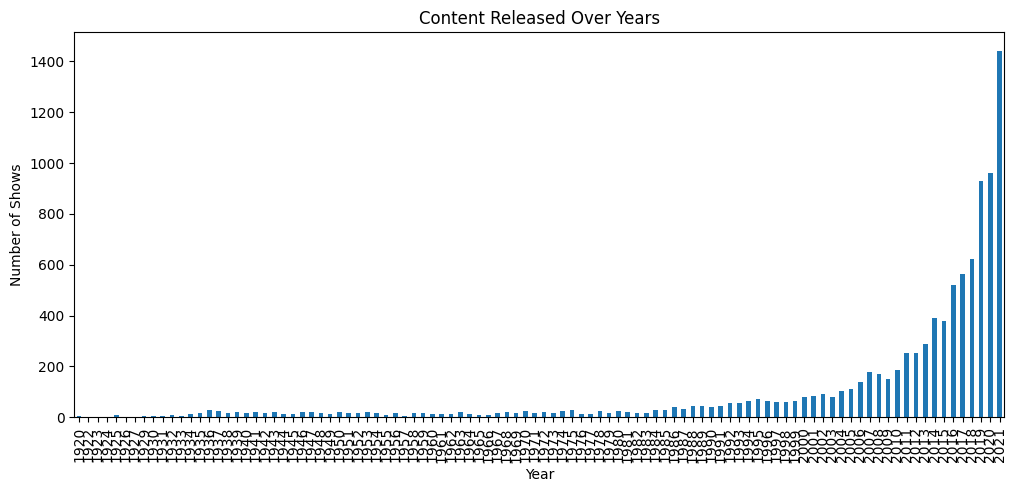

In [14]:
# Content Release over Time 
plt.figure(figsize=(12,5))
release_data.plot(kind='bar')
plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

In [15]:
df_country = df[df['country'] != 'Unknown']

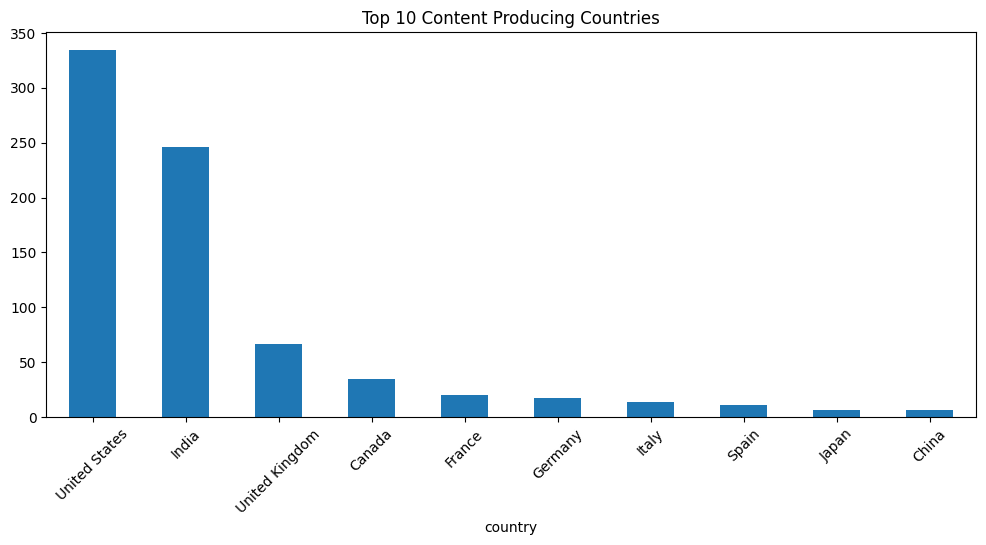

In [16]:
# Top Countries
df_country = df[df['country'] != 'Unknown'].copy()
df_country['country'] = df_country['country'].str.split(', ')
df_country = df_country.explode('country')
top_countries = df_country['country'].value_counts().head(10)
plt.figure(figsize=(12,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xticks(rotation=45)
plt.show()

### Insights 
- After reading these, the United States emerged as the TOP Content producer.
- India and United Kingdom also contribute significantly.

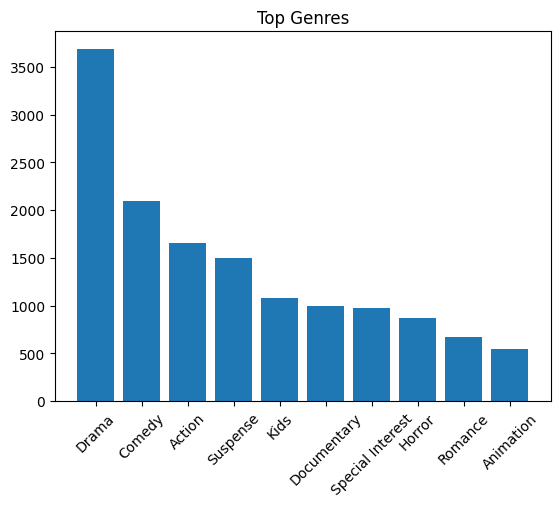

In [17]:
# Most popular Genres
from collections import Counter
genres = df['listed_in'].str.split(', ')
all_genres = sum(genres, [])
genre_count = Counter(all_genres)
top_genres = dict(sorted(genre_count.items(), key=lambda x: x[1], reverse=True)[:10])
plt.bar(top_genres.keys(), top_genres.values())
plt.xticks(rotation=45)
plt.title("Top Genres")
plt.show()

### Insights
- Drama and Comedy are the most popular Genres.
- Action and Thriller also have signifcant presence.

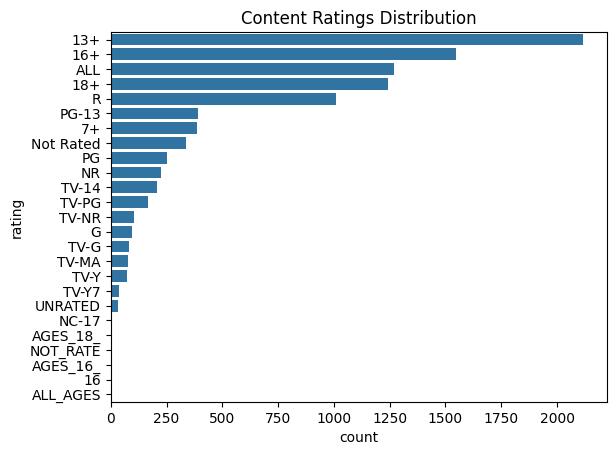

In [18]:
# Ratings Analysis
sns.countplot(y='rating',data=df,order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

### Insight
- Most content is rated for mature audiences.
- Family-friendly content is comparatively less.

In [19]:
# Duration Analysis
df['duration'].value_counts().head(10)

duration
1 Season     1342
2 Seasons     229
90 min        223
91 min        220
92 min        203
89 min        195
88 min        188
94 min        177
93 min        162
87 min        162
Name: count, dtype: int64

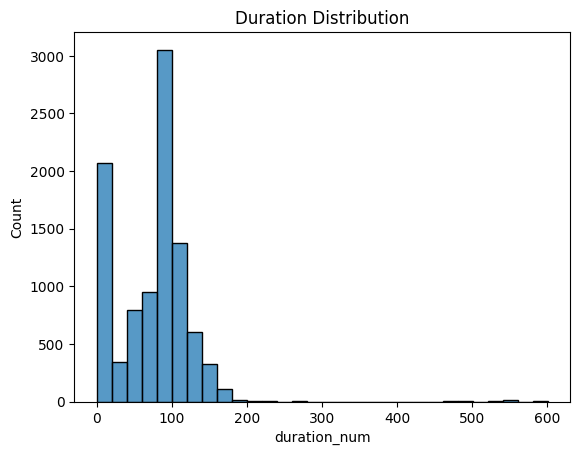

In [20]:
# Movies duration cleaning
df['duration_num'] = df['duration'].str.extract(r'(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'])
sns.histplot(df['duration_num'].dropna(), bins=30)
plt.title("Duration Distribution")
plt.show()

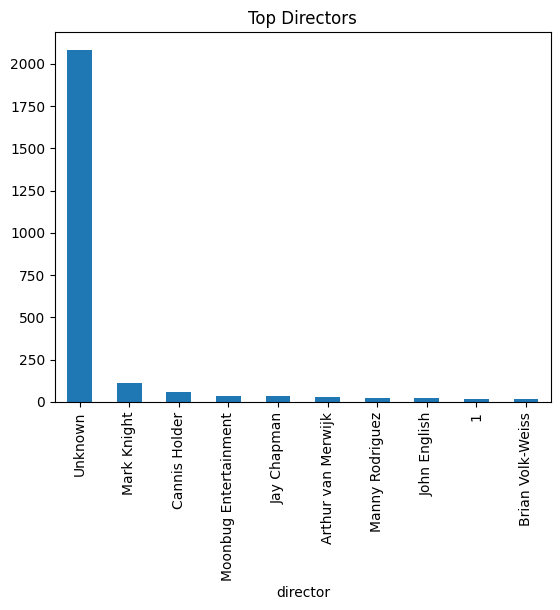

In [21]:
# Top Directors
df['director'].value_counts().head(10).plot(kind='bar')
plt.title("Top Directors")
plt.show()

# ✅ Conclusion

- Amazon Prime has a larger collection of Movies compared to TV Shows.
- Content production has significantly increased after 2015.
- USA dominates the content library, followed by India and UK.
- Drama and Comedy are the most common genres.
- Most content is targeted towards mature audiences.

Overall, Amazon Prime Video has expanded its content library rapidly, focusing on diverse genres and global audiences.